# Módulo 13 · LSTM para ventas de alcohol

Curso: **Series Temporales con R y Python** (Frogames Formación).

Código de acompañamiento de las lecciones `03-ventanas-timeseriesgenerator-a-sequence` y
`04-lstm-entrenamiento-prediccion-guardado`. Dataset: ventas mensuales de alcohol en EEUU
(FRED, serie `S4248SM144NCEN`, `Alcohol_Sales.csv` en esta misma carpeta).

Este notebook trae dos fixes reales de Keras 3, explicados con detalle en las lecciones:
1. `keras.preprocessing.sequence.TimeseriesGenerator` fue **eliminado en Keras 3, sin reemplazo
   directo** → se reimplementa aquí como una `keras.utils.Sequence` mínima.
2. `model.save('*.h5')` + `load_model('*.h5')` con Keras 3 **rompe** al cargar (bug real del
   deserializador con el formato HDF5 legado) → se usa el formato nativo `.keras`.

## Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

df = pd.read_csv('Alcohol_Sales.csv', index_col='DATE', parse_dates=True)
df.index.freq = 'MS'
df.columns = ['Sales']
df.head()

,Sales
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221


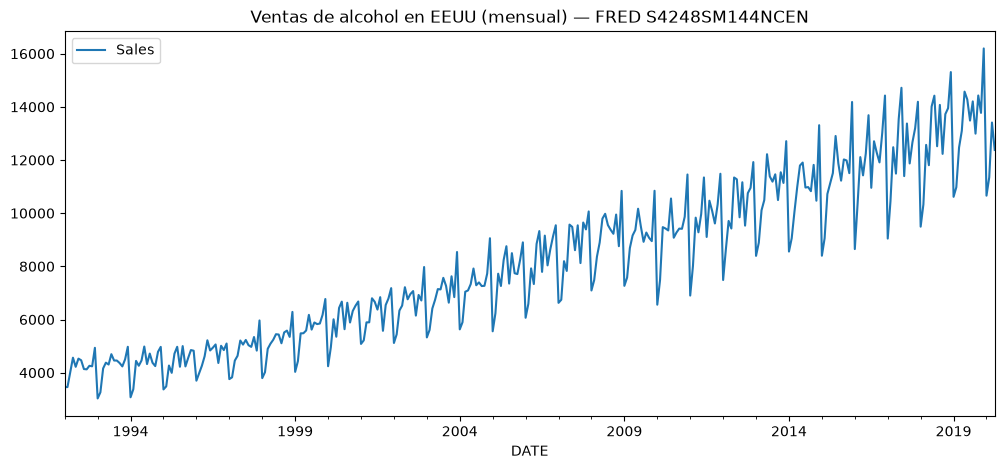

In [2]:
df.plot(figsize=(12, 5))
plt.title("Ventas de alcohol en EEUU (mensual) — FRED S4248SM144NCEN")
plt.show()

## Train / test split

Los últimos 12 meses se reservan como test — nunca al azar, siempre respetando el orden temporal.

In [3]:
train = df.iloc[:len(df) - 12]
test = df.iloc[len(df) - 12:]
print("train:", len(train), "test:", len(test))

train: 328 test: 12


## Escalando los datos

`MinMaxScaler` se ajusta **solo con `train`** y se aplica después a `test` — igual que en cualquier otro
módulo del curso, para no filtrar información del futuro al ajuste.

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

## Ventanas de entrada: de `TimeseriesGenerator` a `keras.utils.Sequence`

El curso original de Udemy usaba `keras.preprocessing.sequence.TimeseriesGenerator` para trocear la
serie en ventanas `(X, y)`: `length` pasos de historia como entrada, el siguiente paso como objetivo.
**Keras 3 eliminó esta clase sin sustituto directo.** La reimplementamos aquí como una
`keras.utils.Sequence` con la misma interfaz — `generator[i]` para acceder a un batch, `len(generator)`
para el número de batches — de forma que el resto del código (incluido `model.fit(generator, ...)`) no
tenga que cambiar.

In [5]:
class TimeseriesGenerator(keras.utils.Sequence):
    """Reemplazo de keras.preprocessing.sequence.TimeseriesGenerator (eliminado en Keras 3,
    sin sustituto directo). Misma interfaz: generator[i], len(generator)."""

    def __init__(self, data, targets, length, batch_size=1, **kwargs):
        super().__init__(**kwargs)
        self.data = data
        self.targets = targets
        self.length = length
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil((len(self.data) - self.length) / self.batch_size))

    def __getitem__(self, index):
        i = index * self.batch_size
        rows = range(i, min(i + self.batch_size, len(self.data) - self.length))
        X = np.array([self.data[r:r + self.length] for r in rows])
        y = np.array([self.targets[r + self.length] for r in rows])
        return X, y

In [6]:
n_input = 2
n_features = 1
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

print("len(generator) con n_input=2:", len(generator))
X, y = generator[0]
print(f"Datos: \n{X.flatten()}")
print(f"Predicción: \n{y}")

len(generator) con n_input=2: 326
Datos: 
[0.03486194 0.03478048]
Predicción: 
[[0.07909098]]


In [7]:
# Redefinimos para que use 12 meses de historia y prediga el mes siguiente
n_input = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)
print("len(generator) con n_input=12:", len(generator))
X, y = generator[0]
print(f"Dado el array: \n{X.flatten()}")
print(f"Predecir este y: \n{y}")

len(generator) con n_input=12: 316
Dado el array: 
[0.03486194 0.03478048 0.07909098 0.12486764 0.09692922 0.12201678
 0.11688523 0.09008715 0.08919117 0.10002444 0.09847683 0.1551682 ]
Predecir este y: 
[[0.]]


## Creando el modelo LSTM

In [8]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

keras.utils.set_random_seed(101)

model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(n_input, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()

/Users/juangabriel/.cache/uv/archive-v0/qtb76UbI2bqualdl/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

`model.fit_generator()` fue eliminado de Keras — el generador (o `Sequence`) se pasa directamente a
`model.fit()`.

In [9]:
history = model.fit(generator, epochs=50, verbose=0)
print("loss epoch 1: ", history.history['loss'][0])
print("loss epoch 25:", history.history['loss'][24])
print("loss epoch 50:", history.history['loss'][-1])

loss epoch 1:  0.019088448956608772
loss epoch 25: 0.001430389005690813
loss epoch 50: 0.0013637718511745334


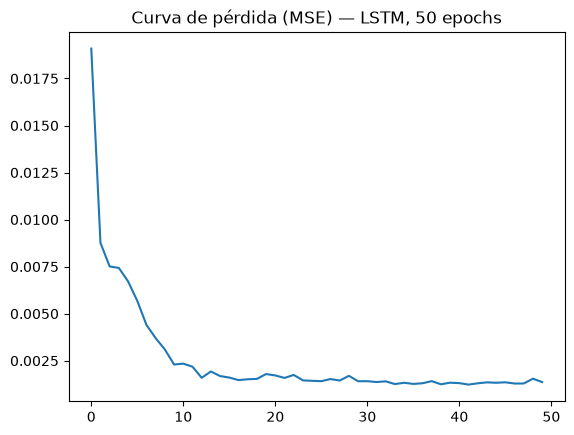

In [10]:
plt.plot(range(len(history.history['loss'])), history.history['loss'])
plt.title("Curva de pérdida (MSE) — LSTM, 50 epochs")
plt.show()

## Evaluando en los datos de prueba (test)

Predicción **iterativa**: se predice un paso, ese paso predicho entra como si fuera dato real en la
ventana de entrada, y se predice el siguiente — así hasta cubrir los 12 meses de test.

In [11]:
test_predictions = []

first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):
    current_pred = model.predict(current_batch, verbose=0)[0]
    test_predictions.append(current_pred)
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

## Transformación inversa y comparación

In [12]:
true_predictions = scaler.inverse_transform(test_predictions)
test['Predictions'] = true_predictions
test

,Sales,Predictions
DATE,,
2019-05-01,14573,14331.141851
2019-06-01,14277,14577.231905
2019-07-01,13484,13262.136772
2019-08-01,14205,14391.318647
2019-09-01,12992,12979.045691
2019-10-01,14427,14259.679025
2019-11-01,13773,14531.334796
2019-12-01,16197,15476.547714
2020-01-01,10659,11043.559885


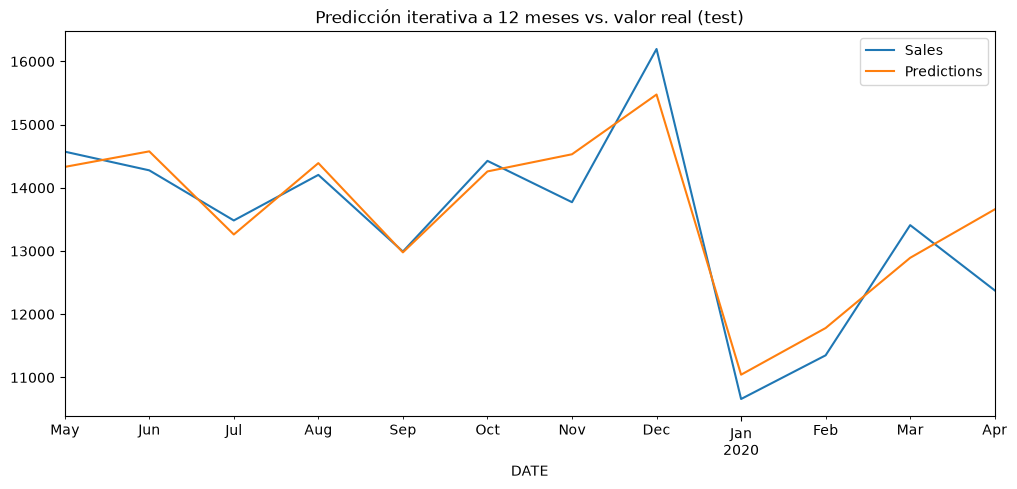

In [13]:
test.plot(figsize=(12, 5))
plt.title("Predicción iterativa a 12 meses vs. valor real (test)")
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = mean_squared_error(test['Sales'], test['Predictions']) ** 0.5
mae = mean_absolute_error(test['Sales'], test['Predictions'])
print("RMSE test:", rmse)
print("MAE test:", mae)

RMSE test: 547.5380459888656
MAE test: 435.324414635698


## Guardar y cargar el modelo

Con Keras 3, `model.save('modelo.h5')` sigue "funcionando" al guardar, pero `load_model('modelo.h5')`
falla de verdad — no es un problema de nuestro código, es un bug del deserializador del formato HDF5
legado con métricas de Keras 3. Lo reproducimos para verlo con nuestros propios ojos antes de usar el
formato correcto.

In [15]:
# Esto es lo que YA NO funciona en Keras 3 (se documenta el error real, no es el flujo recomendado):
try:
    model.save('lstm_alcohol_sales_LEGADO.h5')
    from keras.models import load_model
    load_model('lstm_alcohol_sales_LEGADO.h5')
    print(".h5 cargó sin problema (inesperado)")
except Exception as e:
    print(f"Error real al cargar .h5 en Keras 3: {type(e).__name__}: {e}")

Error real al cargar .h5 en Keras 3: ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass


In [16]:
# Lo correcto en Keras 3: el formato nativo .keras
model.save('lstm_alcohol_sales.keras')

from keras.models import load_model
new_model = load_model('lstm_alcohol_sales.keras')
new_model.summary()

/Users/juangabriel/.cache/uv/archive-v0/qtb76UbI2bqualdl/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 7 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(store)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,804 (319.55 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,903 (159.78 KB)

In [17]:
check = new_model.predict(first_eval_batch.reshape((1, n_input, n_features)), verbose=0)
original = model.predict(first_eval_batch.reshape((1, n_input, n_features)), verbose=0)
print("misma predicción tras cargar:", np.allclose(check, original))

misma predicción tras cargar: True
